In [1]:
import networkx as nx
import torch
import torch.nn.functional as F
import numpy as np
import random
import copy
import matplotlib.pyplot as plt
from torch_geometric.datasets import Planetoid
from networkx.generators.community import stochastic_block_model, LFR_benchmark_graph
from torch_geometric.utils import from_networkx, dropout_adj, to_networkx, to_undirected, dropout_edge
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
def load_commu_data(data_name):
    if data_name in ["Cora", "Citeseer", "Pubmed"]:
        dataset = Planetoid(root="dataset", name=data_name)
        data = dataset[0]
    data.edge_index = to_undirected(data.edge_index)
    G = to_networkx(data)
    communities = nx.community.louvain_communities(G, resolution=0.5)
    probs = np.zeros((len(communities), len(communities)))
    sizes = []
    for idx, c in enumerate(communities):
        sizes.append(len(c))
        for n in c:
            G.nodes[n]["com"] = idx # get com label
    for u, v in zip(data.edge_index[0], data.edge_index[1]): # count number of edge per com
        u = float(u)
        v = float(v)
        probs[G.nodes[u]["com"], G.nodes[v]["com"]] += 1
    for x in range(len(probs)): # make the probs
        for y in range(len(probs)):
            if x == y:
                probs[x,x] /= (sizes[x]*(sizes[x]-1))/2
            else:
                probs[x,y] /= ((sizes[x]+sizes[y])*(sizes[x]+sizes[y]-1))/2
    probs /= 2 # undirected graph
    data.community = communities
    data.probs = probs
    data.sizes = sizes
    data.num_features = data.num_nodes
    data.x = F.one_hot(torch.arange(0, data.num_nodes)).float()
    if device is not None:
        data = data.to(device)
    print(np.round(probs, 5))
    return data

data = load_commu_data("Cora")

[[1.      0.      0.      ... 0.      0.      0.     ]
 [0.      1.      0.      ... 0.      0.      0.     ]
 [0.      0.      0.00794 ... 0.      0.      0.     ]
 ...
 [0.      0.      0.      ... 1.      0.      0.     ]
 [0.      0.      0.      ... 0.      1.      0.     ]
 [0.      0.      0.      ... 0.      0.      1.     ]]


In [3]:
print(len(data.probs))

91


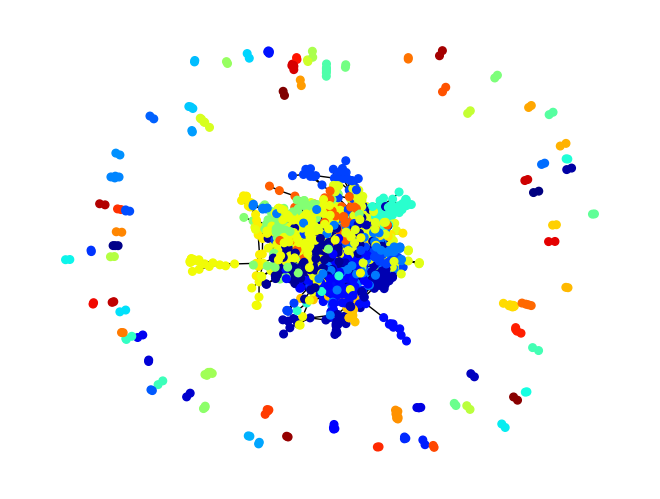

In [4]:
G = to_networkx(data, to_undirected=True)
community_dict = {}
for community_id, community in enumerate(data.community):
    for node in community:
        community_dict[node] = community_id
values = [community_dict[node] for node in G.nodes()]
pos = nx.spring_layout(G)
nx.draw(G, pos, node_size=30, cmap = plt.get_cmap('jet'), node_color = values)

Data(edge_index=[2, 9960], block=[2708], partition=[91], name='stochastic_block_model', num_nodes=2708, sizes=[91], probs=[91, 91], num_features=2708, x=[2708, 2708])


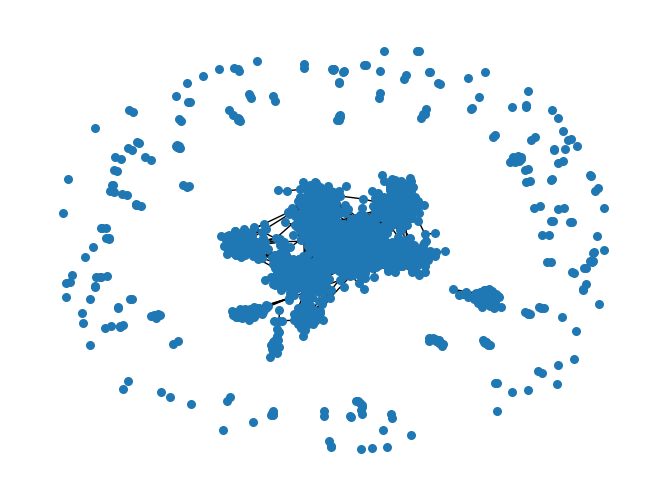

In [6]:
def gen_sbm(sizes, probs, device=None, seed=random.randint(1, 10000), draw=False):
    G = stochastic_block_model(sizes, probs, seed=seed)
    G.remove_edges_from(nx.selfloop_edges(G)) # remove self loops
    if draw:
        pos = nx.spring_layout(G)
        nx.draw(G, pos, node_size=30)
    #plt.savefig(f'{random.randint(0, 10000)}sbm.png')
    data = from_networkx(G)
    data.num_nodes = sum(sizes)
    data.sizes = sizes
    data.probs = probs
    data.num_features = data.num_nodes
    data.x = F.one_hot(torch.arange(0, sum(sizes))).float()
    if device is not None:
        data = data.to(device)
    return data
data = gen_sbm(data.sizes, data.probs, device, 0, True)
print(data)

max_value 1.0
torch.Size([2, 9778])


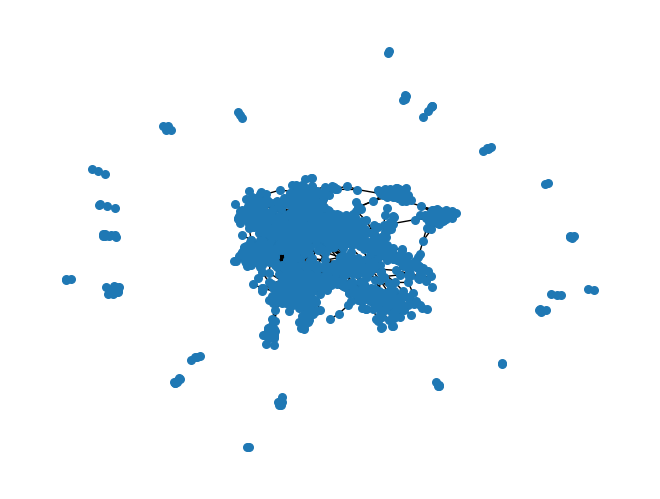

In [6]:
def deplete(data, rm: float = 0.2):
    data_poor = copy.deepcopy(data)
    data_poor.to(data.x.device)
    G = to_networkx(data_poor, to_undirected=True)
    max_value = np.max(data_poor.probs)
    print("max_value", max_value)
    index_1, index_2 = np.where(data_poor.probs == max_value)
    for i, j in list(zip(index_1, index_2)):
        if i == j:
            nodes = torch.nonzero(data_poor.block==i).squeeze(1)
        else:
            nodes_1 = torch.nonzero(data_poor.block==i).squeeze(1)
            nodes_2 = torch.nonzero(data_poor.block==j).squeeze(1)
            nodes = torch.cat((nodes_1, nodes_2))
        edges_in_community = [(u, v) for u in nodes.tolist() for v in nodes.tolist() if G.has_edge(u, v)]
        edges_to_remove = random.sample(edges_in_community, int(rm*len(edges_in_community)))
        G.remove_edges_from(edges_to_remove)
    data_poor = from_networkx(G)
    pos = nx.spring_layout(G)
    G.remove_nodes_from(list(nx.isolates(G)))
    nx.draw(G, pos, node_size=30, cmap = plt.get_cmap('jet'))
    print(data_poor.edge_index.shape)
    return data_poor
poor_data = deplete(data, 0.5)